<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/Credit_Card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Decision Tree

In [2]:
df=pd.read_csv('creditcard.csv')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df_cleaned = df.dropna(subset=['Class'])
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (26404, 30)
X_test shape: (11317, 30)
y_train shape: (26404,)
y_test shape: (11317,)


In [19]:
dt_model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model_entropy.fit(X_train, y_train)

print("Decision Tree model (with entropy criterion) trained successfully!")

Decision Tree model (with entropy criterion) trained successfully!


In [20]:
y_pred_entropy = dt_model_entropy.predict(X_test)

Accuracy (Entropy): 0.9992
Precision (Entropy): 0.7895
Recall (Entropy): 0.9677
F1-Score (Entropy): 0.8696


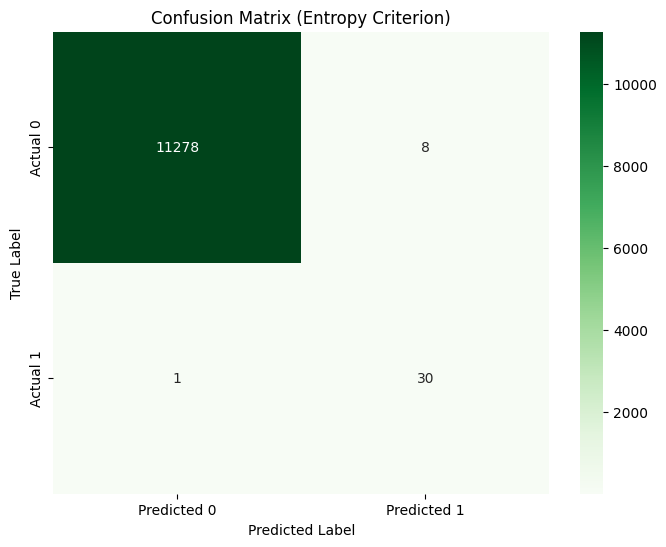

In [21]:
# Calculate evaluation metrics for entropy model
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
precision_entropy = precision_score(y_test, y_pred_entropy)
recall_entropy = recall_score(y_test, y_pred_entropy)
f1_entropy = f1_score(y_test, y_pred_entropy)
conf_matrix_entropy = confusion_matrix(y_test, y_pred_entropy)

print(f"Accuracy (Entropy): {accuracy_entropy:.4f}")
print(f"Precision (Entropy): {precision_entropy:.4f}")
print(f"Recall (Entropy): {recall_entropy:.4f}")
print(f"F1-Score (Entropy): {f1_entropy:.4f}")

# Plot Confusion Matrix for entropy model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_entropy, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Entropy Criterion)')
plt.show()

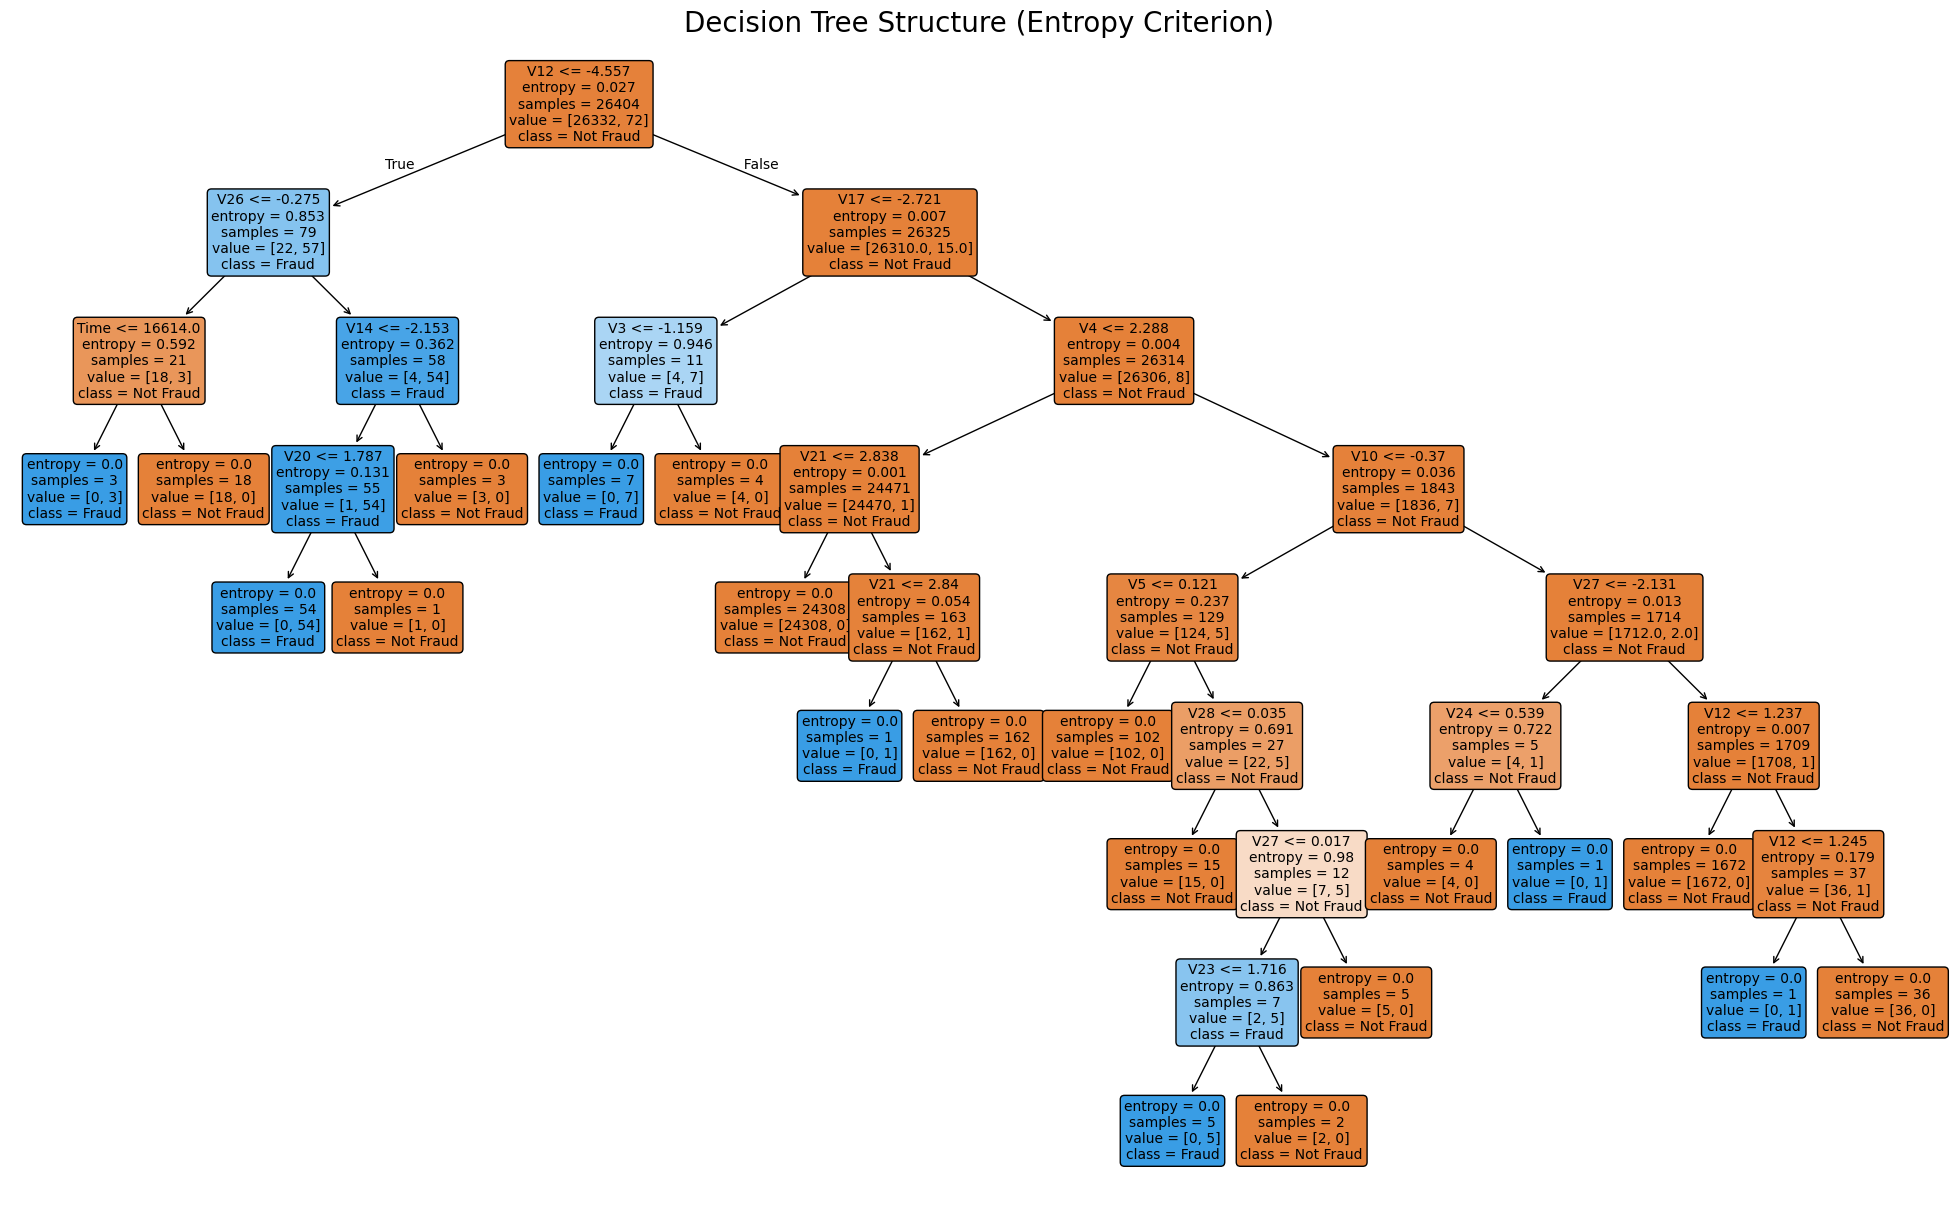

In [22]:
plt.figure(figsize=(25, 15)) # Set a large figure size for better readability
from sklearn.tree import plot_tree

# Get feature names from the training data
feature_names = X_train.columns.tolist()

plot_tree(dt_model_entropy,
          feature_names=feature_names,
          class_names=['Not Fraud', 'Fraud'], # Assuming 0 for Not Fraud, 1 for Fraud
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Entropy Criterion)', fontsize=20)
plt.show()

In [15]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")
dt_model

Decision Tree model trained successfully!


DecisionTreeClassifier(random_state=42)

In [16]:
y_pred = dt_model.predict(X_test)

Accuracy: 0.9990
Precision: 0.7632
Recall: 0.9355
F1-Score: 0.8406


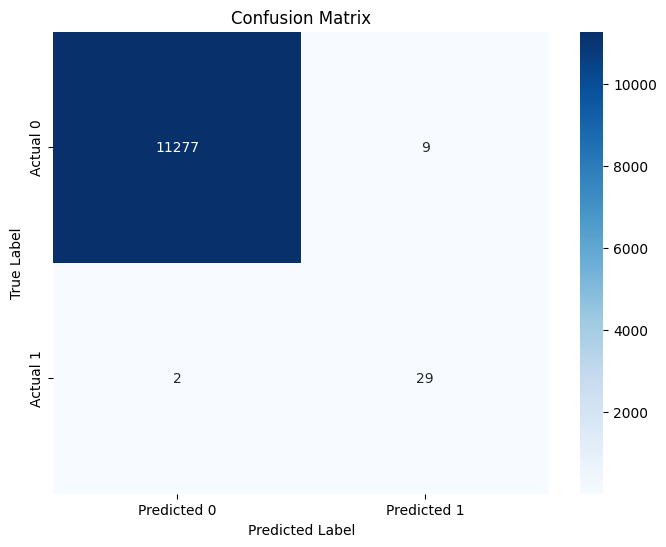

In [17]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

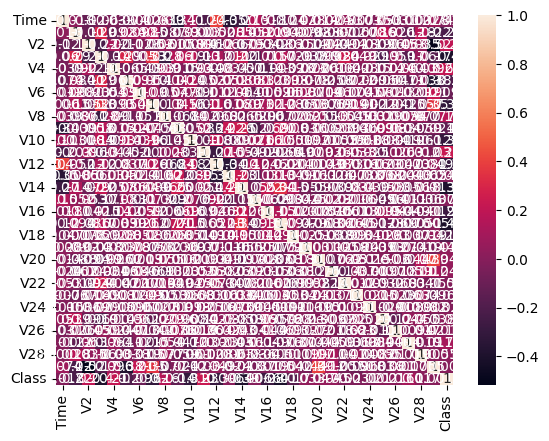

In [18]:
dt_heat=sns.heatmap(df_cleaned.corr(),annot=True)

SUPPORT VECTOR MACHINE (SVM)

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the SVM model
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully!")
svm_model

Support Vector Machine model trained successfully!


SVC()

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)


In [36]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

Accuracy (SVM): 0.9973
Precision (SVM): 0.0000
Recall (SVM): 0.0000
F1-Score (SVM): 0.0000


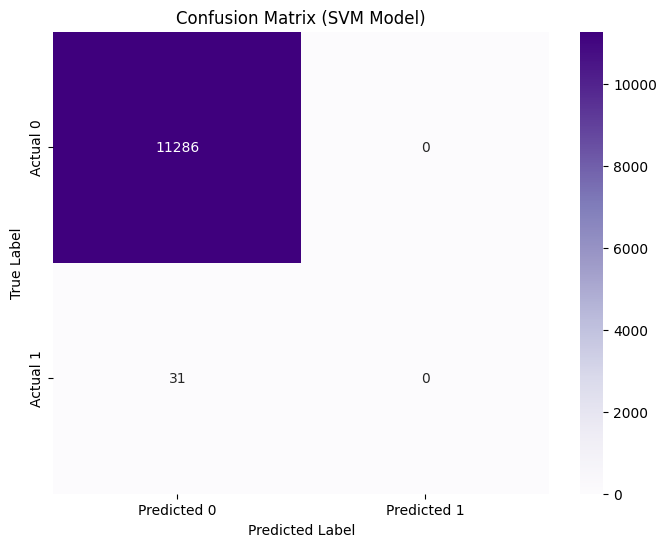

In [37]:
# Calculate evaluation metrics for SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"Accuracy (SVM): {accuracy_svm:.4f}")
print(f"Precision (SVM): {precision_svm:.4f}")
print(f"Recall (SVM): {recall_svm:.4f}")
print(f"F1-Score (SVM): {f1_svm:.4f}")

# Confusion Matrix for SVM model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM Model)')
plt.show()